# **Medical Insurance Cost Prediction**
## __Exploratary Data Analysis__

## Import Libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load Dataset

In [15]:
df=pd.read_csv("../data/insurance.csv")
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


## Dataset overview

In [16]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


As we can see the dataset contains total 1338 rows and 7 columns.All features contain appropriate data types and no missing values.These statistics also indictes that "charges" column contains wide range and have high valueed outliers.

## Data Quality Assessment

### Checking duplicate and null values

In [17]:
print(df.isnull().sum())
print("Duplicate values:",df.duplicated().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicate values: 1


No missing Values, 1 duplicate is found so it will be retained since it's a negligible fraction of the dataset and won't meaningfully affect analysis.

### Check Inconsistent values or any kind of typo

In [18]:
print(df["sex"].unique()) #checking inconsistent values
print(df["region"].unique())
print(df["smoker"].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str


## Checking outliers

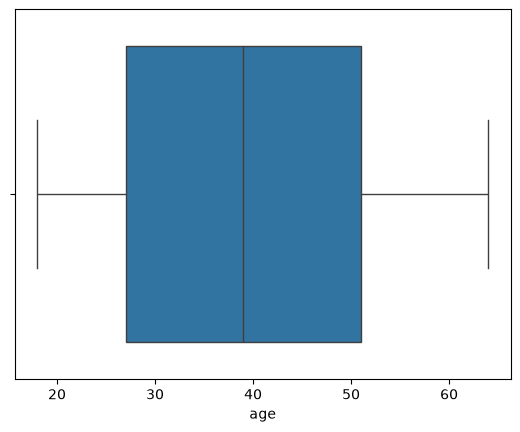

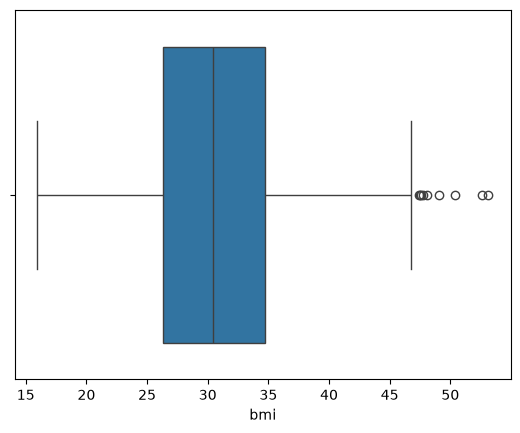

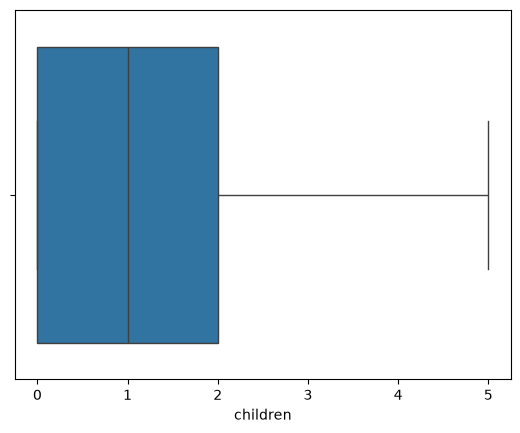

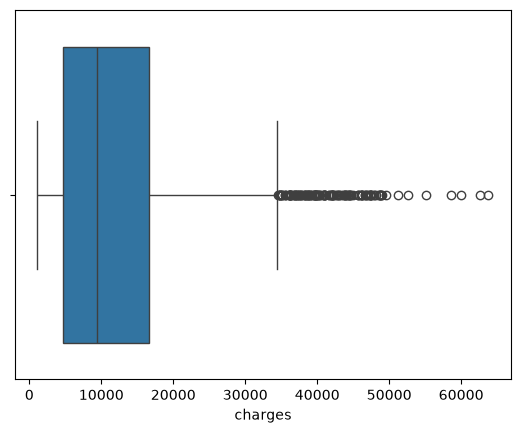

In [19]:
numeric_cols=df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    sns.boxplot(data=df, x=col)
    plt.show()



These graphs clearly shows the outliers in "bmi" and "charges", Lets have an eye on these outliers

In [20]:
print("================== Data with high charges Values =====================")
df[df["charges"]>40000].head(30)


================== Data with high charges Values =====================


,age,sex,bmi,children,smoker,region,charges
34,28,male,36.400,1,yes,southwest,51194.55914
39,60,male,39.900,0,yes,southwest,48173.36100
55,58,male,36.955,2,yes,northwest,47496.49445
86,57,female,31.160,0,yes,northwest,43578.93940
94,64,female,31.300,2,yes,southwest,47291.05500
109,63,male,35.090,0,yes,southeast,47055.53210
146,46,male,30.495,3,yes,northwest,40720.55105
175,63,female,37.700,0,yes,southwest,48824.45000
185,36,male,41.895,3,yes,northeast,43753.33705
251,63,female,32.200,2,yes,southwest,47305.30500


In [21]:
print("================== Data without extreme outlier Values =====================")
df[df["charges"]<40000].head(20)

================== Data without extreme outlier Values =====================


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


From above dataset analysis we get to know that the "Charges" outliers are not the Wrong entries, these are the original values in which the older persons with high bmi value and are smokers are alloted with high charges as compared to the younger smokers with low bmi

## Univariate Analysis of all Columns

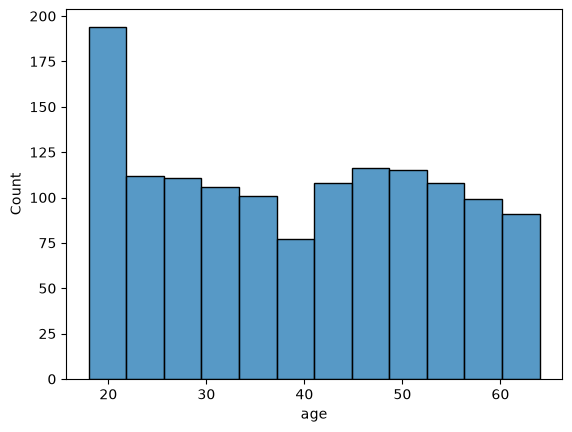

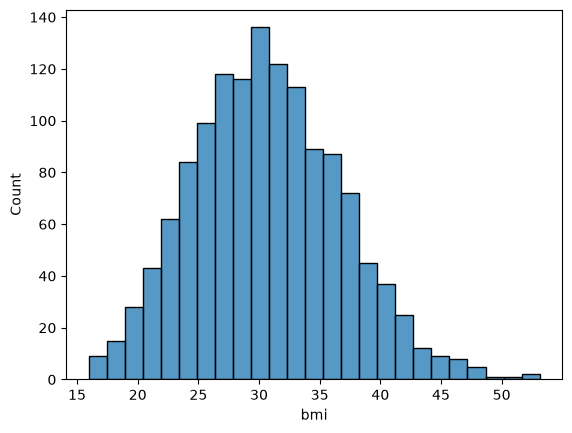

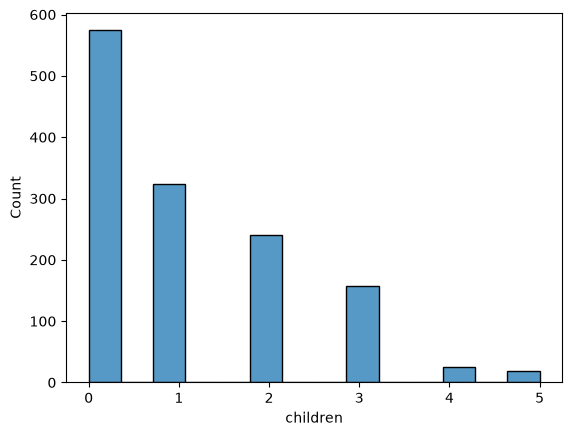

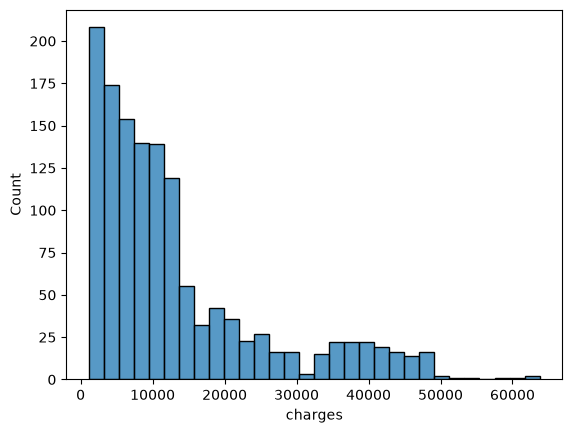

In [22]:
for cols in numeric_cols:
    sns.histplot(data=df,x=cols)
    plt.show()

### Observation:
- Age ranges from 18 to 64 years with more individuals in the range of 18 to 21 age groups, remaining ages are evenly distributed.
- BMI Values are concentrated between 22 to 37 and the graph is slightly right skewed.
- Most individuals have 0 to 1 Children.
- Charges are highly right skewed.

## Now for Categorical Analysis

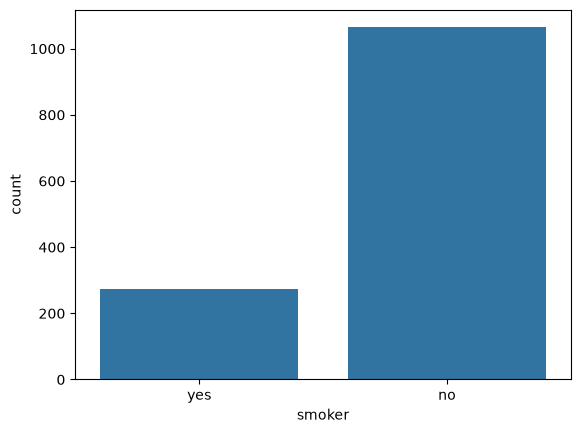

In [ ]:
sns.countplot(x=df["smoker"])
plt.show()
sns.countplot(x=df["region"])
plt.show()
sns.countplot(x=df["sex"])
plt.show()

    


### Observation:
- Most of the individuals are non somkers
- The four regions are fairy balanced
- The dataset contains the balanced distribution of males and females

## Correlation analysis

### Smoker vs Charges

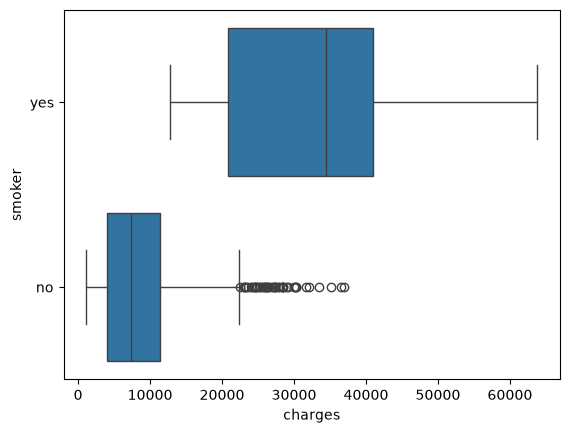

In [ ]:
sns.boxplot(data=df,x='charges',y='smoker')
plt.show()

It clearly indicates that Smokers generally have substantially higher insurance charges than non-smokers.

### Gender vs Charges

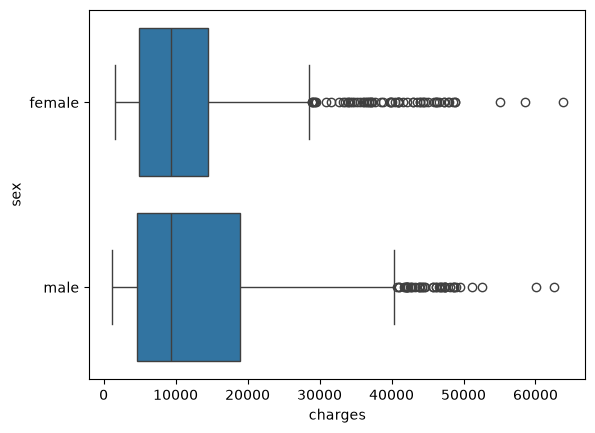

In [ ]:
sns.boxplot(data=df,x='charges',y='sex')
plt.show()

This graph indicates that sex does not appear to have a strong relationship with charges.

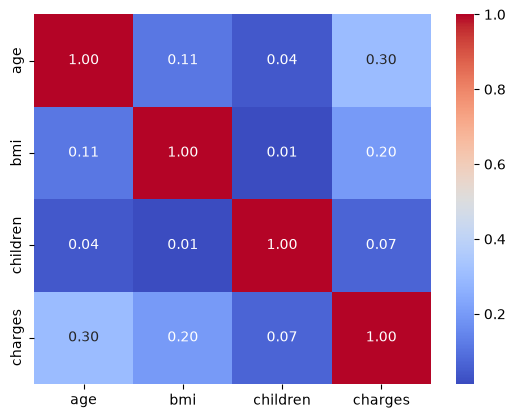

In [ ]:
numeric_cols=df.select_dtypes(include=['float64','int64']).columns

corr= df[numeric_cols].corr()
sns.heatmap(corr, annot=True,cmap='coolwarm',fmt='.2f')
plt.show()

### What we have observed from all these Correlaton graphs?
- Smoker has the strongest positive effect on medical charges, making it an important predictor for the model.
- Age has the strongest correlation with charges among numerical features (0.30).
- BMI has a weak positive correlation (0.20).
- Children has almost no correlation (0.07).
- Overall, smoking status is the most influential feature, followed by age.

## Summary
Overall, the dataset is clean and well structured with no missing values, duplicates, inconsistent or invalid values.The distributions of numerical and catgorical data is analyzed and some outlliers are find in BMI and charges but the identified outliers appear to represent legitimate observations, so they will be retained. Their effect will be considered during preprocessing and model selection. So now this dataset is ready for preprocessing.